In [1]:
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Path to the zip file
zip_file_path = '/content/TrainingSet.zip'

# Dictionary to store DataFrames
dataframes = {}

# Limit for the number of rows per dataset
row_limit = 2000

# Open the zip file
with zipfile.ZipFile(zip_file_path, 'r') as z:
    # List all files in the zip
    file_names = z.namelist()
    # Iterate through each file in the zip
    for file_name in file_names:
        if file_name.endswith('.csv'):  # Check if the file is a CSV
            # Read the CSV file into a pandas DataFrame
            with z.open(file_name) as f:
                df_name = file_name.split('.')[0]  # Use the file name without extension as key
                df = pd.read_csv(f)
                # Limit the number of rows for each dataset
                df = df.head(row_limit)
                dataframes[df_name] = df

# Display the keys and sample data
print("Loaded and limited datasets:")
for df_name in dataframes:
    print(f"- {df_name}")

# Unite all datasets
# Step 1: Ensure consistent column alignment
all_columns = set()
for df in dataframes.values():
    all_columns.update(df.columns)  # Collect all unique column names

# Step 2: Reindex datasets to include all columns
aligned_dataframes = []
for df_name, df in dataframes.items():
    df['source'] = df_name  # Add a source column for traceability
    aligned_df = df.reindex(columns=all_columns, fill_value=0)  # Fill missing columns with 0
    aligned_dataframes.append(aligned_df)

# Step 3: Concatenate all datasets
combined_data = pd.concat(aligned_dataframes, ignore_index=True)

print(f"Combined dataset shape (limited): {combined_data.shape}")
print(combined_data.head())


Loaded and limited datasets:
- TrainingSet/ACT10_competition_training
- TrainingSet/ACT11_competition_training
- TrainingSet/ACT12_competition_training
- TrainingSet/ACT13_competition_training
- TrainingSet/ACT14_competition_training
- TrainingSet/ACT15_competition_training
- TrainingSet/ACT1_competition_training
- TrainingSet/ACT2_competition_training
- TrainingSet/ACT3_competition_training
- TrainingSet/ACT4_competition_training
- TrainingSet/ACT5_competition_training
- TrainingSet/ACT6_competition_training
- TrainingSet/ACT7_competition_training
- TrainingSet/ACT8_competition_training
- TrainingSet/ACT9_competition_training
Combined dataset shape (limited): (29384, 11082)
   D_5828  D_5065  D_5594  D_572  D_5278  D_4662  D_10246  D_10827  D_1566  \
0       0       0       0      0       0       0        0        0       0   
1       0       0       0      0       0       0        0        0       0   
2       0       0       0      0       0       0        0        0       0   
3   

In [2]:
# Path to the zip file
zip_file_path = '/content/TestSet.zip'

# Dictionary to store DataFrames
dataframes = {}

# Limit for the number of rows per dataset
row_limit = 2000

# Open the zip file
with zipfile.ZipFile(zip_file_path, 'r') as z:
    # List all files in the zip
    file_names = z.namelist()
    # Iterate through each file in the zip
    for file_name in file_names:
        if file_name.endswith('.csv'):  # Check if the file is a CSV
            # Read the CSV file into a pandas DataFrame
            with z.open(file_name) as f:
                df_name = file_name.split('.')[0]  # Use the file name without extension as key
                df = pd.read_csv(f)
                # Limit the number of rows for each dataset
                df = df.head(row_limit)
                dataframes[df_name] = df

# Display the keys and sample data
print("Loaded and limited datasets:")
for df_name in dataframes:
    print(f"- {df_name}")

# Unite all datasets
# Step 1: Ensure consistent column alignment
all_columns = set()
for df in dataframes.values():
    all_columns.update(df.columns)  # Collect all unique column names

# Step 2: Reindex datasets to include all columns
aligned_dataframes = []
for df_name, df in dataframes.items():
    df['source'] = df_name  # Add a source column for traceability
    aligned_df = df.reindex(columns=all_columns, fill_value=0)  # Fill missing columns with 0
    aligned_dataframes.append(aligned_df)

# Step 3: Concatenate all datasets
combined_test = pd.concat(aligned_dataframes, ignore_index=True)

print(f"Combined dataset shape (limited): {combined_data.shape}")
print(combined_test.head())


Loaded and limited datasets:
- TestSet/ACT10_competition_test
- TestSet/ACT11_competition_test
- TestSet/ACT12_competition_test
- TestSet/ACT13_competition_test
- TestSet/ACT14_competition_test
- TestSet/ACT15_competition_test
- TestSet/ACT1_competition_test
- TestSet/ACT2_competition_test
- TestSet/ACT3_competition_test
- TestSet/ACT4_competition_test
- TestSet/ACT5_competition_test
- TestSet/ACT6_competition_test
- TestSet/ACT7_competition_test
- TestSet/ACT8_competition_test
- TestSet/ACT9_competition_test
Combined dataset shape (limited): (29384, 11082)
   D_5828  D_5065  D_5594  D_572  D_5278  D_4662  D_10246  D_10827  D_1566  \
0       0       0       0      0       0       0        0        0       0   
1       0       0       0      0       0       1        0        0       0   
2       0       0       0      0       0       0        0        0       0   
3       0       0       0      0       0       0        0        0       0   
4       0       0       0      0       0      

In [3]:
from scipy.sparse import csr_matrix
from sklearn.preprocessing import StandardScaler, PowerTransformer
# 2. Handle Sparse Data
if combined_data.isna().sum().sum() > 0:
    combined_data.fillna(0, inplace=True)
features = combined_data.drop(columns=['MOLECULE', 'Act'])
sparse_matrix = csr_matrix(features)
target = combined_data['Act']
print(f"Sparse matrix shape: {sparse_matrix.shape}")

Sparse matrix shape: (29384, 11080)


In [4]:
#Feature Engineering - Normalize or Scale features:
scaler = StandardScaler(with_mean=False)
scaled_features = scaler.fit_transform(sparse_matrix)

In [5]:
## PCA and other dimentionality reduction:
from sklearn.decomposition import PCA
from sklearn.decomposition import KernelPCA
from sklearn.metrics.pairwise import rbf_kernel, polynomial_kernel

dense_features = scaled_features.toarray()
pca = PCA(n_components=2745)
pca_scaled_features = pca.fit_transform(scaled_features)

print(f"PCA explained variance ratio (with scaling): {pca.explained_variance_ratio_}")
print(f"PCA transformed shape: {pca_scaled_features.shape}")

# Kernel PCA (Experiment with kernels):
kernels = ['linear', 'rbf', 'poly']
kernel_scaled_results = {}

for kernel in kernels:
    kpca = KernelPCA(n_components=2745, kernel=kernel, gamma=50)  # Adjust gamma for rbf/poly kernels
    kernel_transformed = kpca.fit_transform(scaled_features)
    kernel_scaled_results[kernel] = kernel_transformed
    print(f"Kernel PCA with {kernel} kernel: Shape {kernel_transformed.shape}")

PCA explained variance ratio (with scaling): [2.76444953e-02 1.87642966e-02 1.22227662e-02 ... 4.02092715e-05
 4.01626334e-05 4.01474183e-05]
PCA transformed shape: (29384, 2745)
Kernel PCA with linear kernel: Shape (29384, 2745)
Kernel PCA with rbf kernel: Shape (29384, 2745)
Kernel PCA with poly kernel: Shape (29384, 2745)


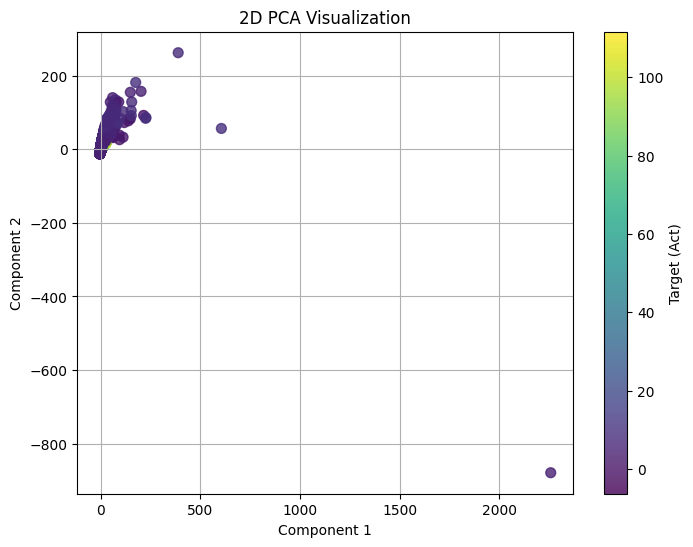

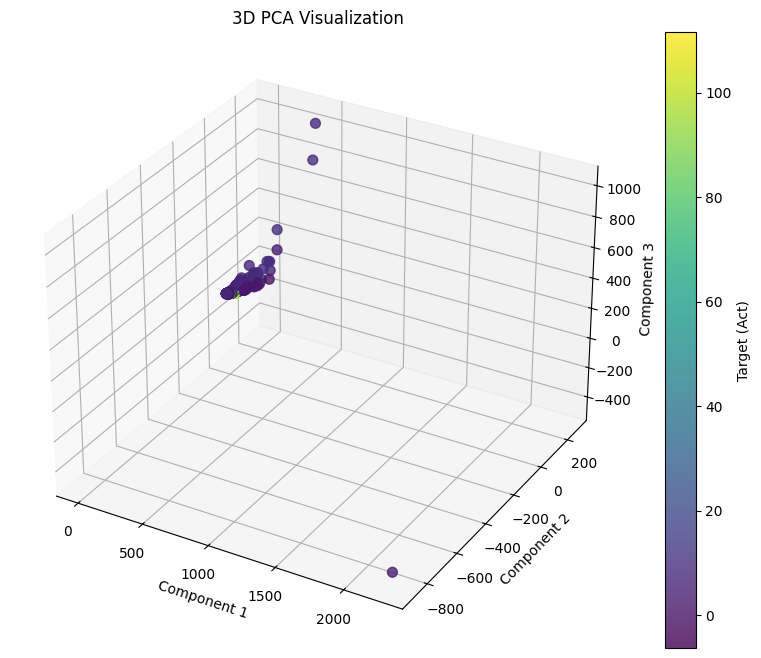

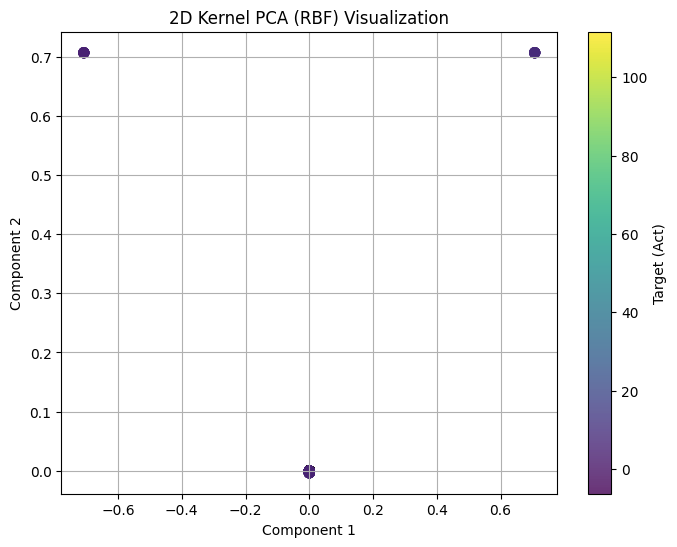

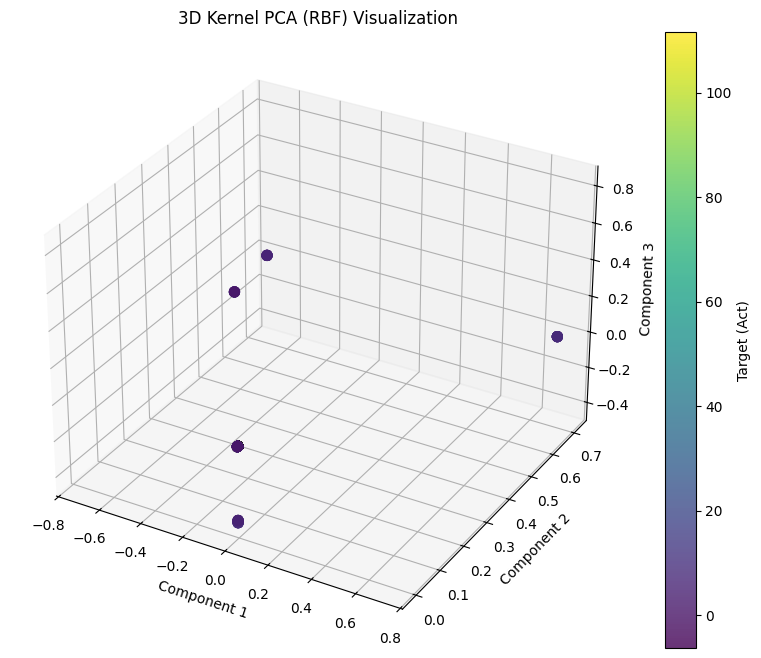

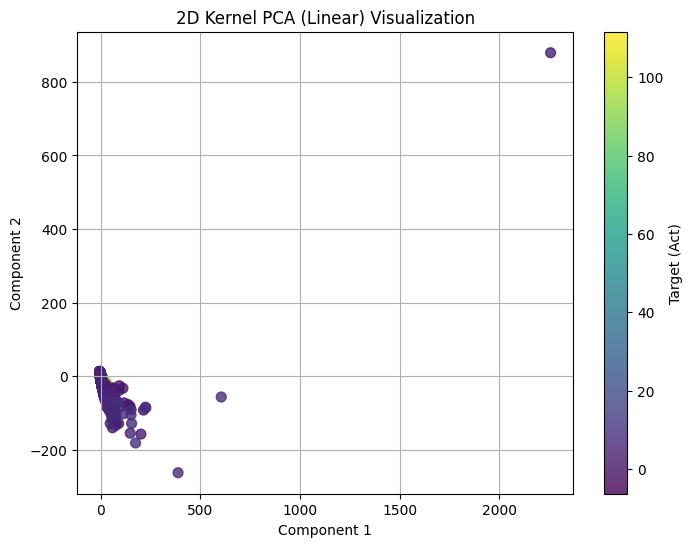

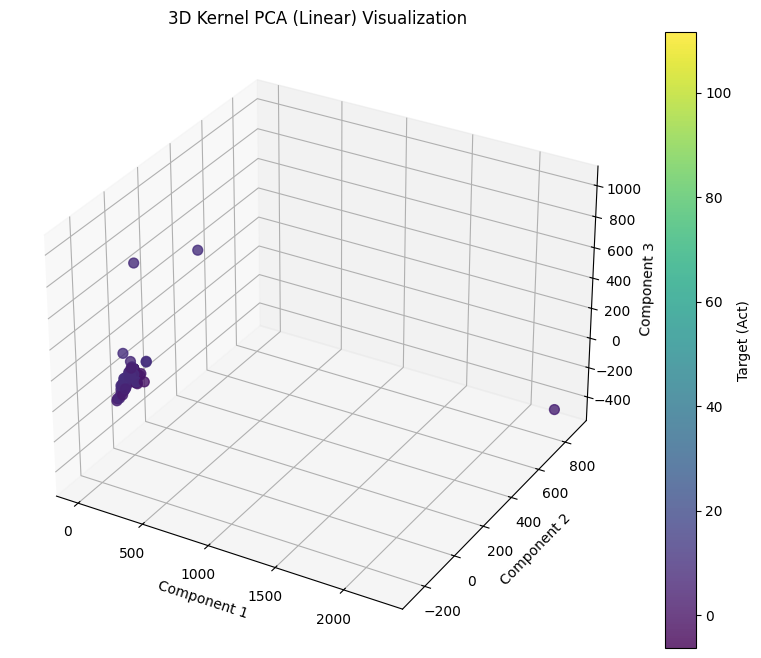

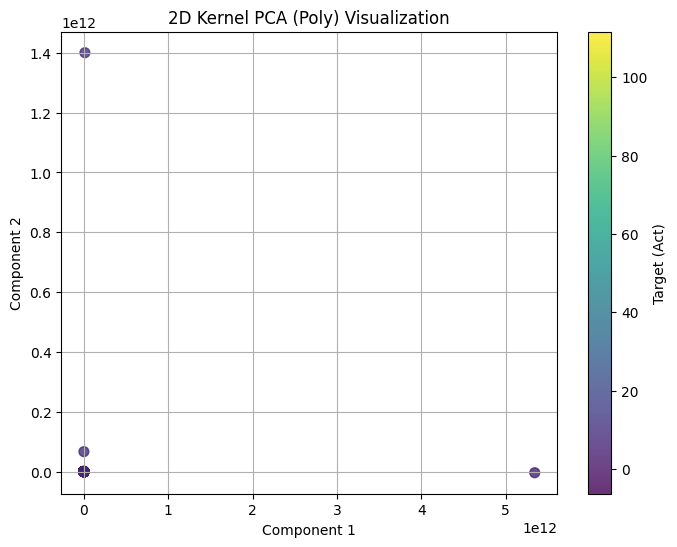

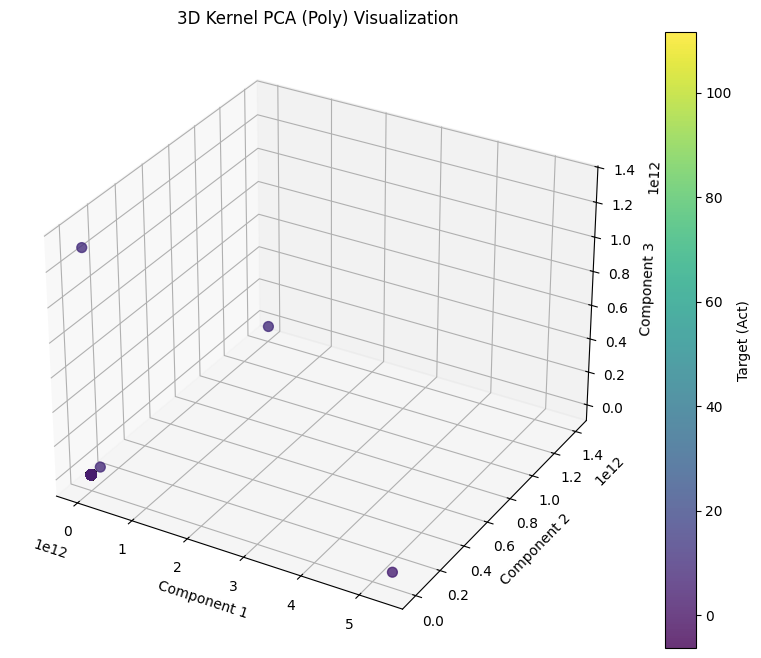

In [9]:
## Data Analysis:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Helper function for 2D visualization:
def visualize_2d(data, target, title, cmap='viridis'):
    plt.figure(figsize=(8, 6))
    plt.scatter(data[:, 0], data[:, 1], c=target, cmap=cmap, s=50, alpha=0.8)
    plt.colorbar(label='Target (Act)')
    plt.title(title)
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.grid(True)
    plt.show()

# Helper function for 3D visualization:
def visualize_3d(data, target, title, cmap='viridis'):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(data[:, 0], data[:, 1], data[:, 2], c=target, cmap=cmap, s=50, alpha=0.8)
    plt.colorbar(scatter, label='Target (Act)')
    ax.set_title(title)
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.set_zlabel('Component 3')
    plt.show()

# Visualize PCA:
visualize_2d(pca_scaled_features, target, title="2D PCA Visualization")
visualize_3d(pca_scaled_features, target, title="3D PCA Visualization")

# Visualize Kernel PCA (RBF Kernel):
visualize_2d(kernel_scaled_results['rbf'], target, title="2D Kernel PCA (RBF) Visualization")
visualize_3d(kernel_scaled_results['rbf'], target, title="3D Kernel PCA (RBF) Visualization")

# Visualize Kernel PCA (Linear Kernel):
visualize_2d(kernel_scaled_results['linear'], target, title="2D Kernel PCA (Linear) Visualization")
visualize_3d(kernel_scaled_results['linear'], target, title="3D Kernel PCA (Linear) Visualization")

# Visualize Kernel PCA (Poly Kernel):
visualize_2d(kernel_scaled_results['poly'], target, title="2D Kernel PCA (Poly) Visualization")
visualize_3d(kernel_scaled_results['poly'], target, title="3D Kernel PCA (Poly) Visualization")

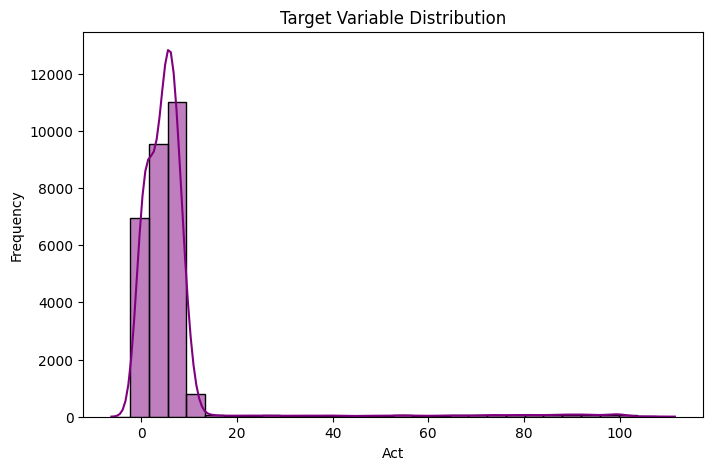

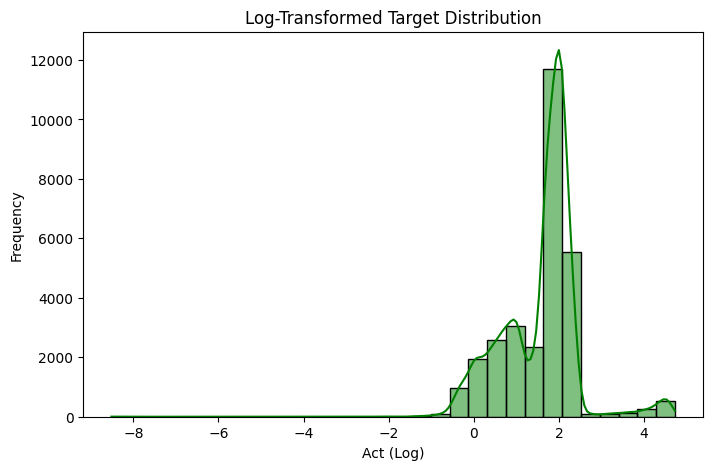

In [10]:
 # 4. Target Analysis:
# Distribution of Act:
plt.figure(figsize=(8, 5))
sns.histplot(combined_data['Act'], kde=True, bins=30, color='purple')
plt.title('Target Variable Distribution')
plt.xlabel('Act')
plt.ylabel('Frequency')
plt.show()

# Log transformation if Act is highly skewed:
if combined_data['Act'].skew() > 1:
    combined_data['Act_log'] = np.log1p(combined_data['Act'])
    plt.figure(figsize=(8, 5))
    sns.histplot(combined_data['Act_log'], kde=True, bins=30, color='green')
    plt.title('Log-Transformed Target Distribution')
    plt.xlabel('Act (Log)')
    plt.ylabel('Frequency')
    plt.show()

In [6]:
# Save the processed data for modeling:
pca_processed_data = pd.DataFrame(pca_scaled_features, columns=[f'Feature_{i}' for i in range(pca_scaled_features.shape[1])])
pca_processed_data['Act'] = combined_data['Act']
pca_processed_data['MOLECULE'] = combined_data['MOLECULE']

processed_kernel_dict = {}
for kernel, data in kernel_scaled_results.items():
    scaled_data_df = pd.DataFrame(data, columns=[f'Feature_{i}' for i in range(data.shape[1])])
    scaled_data_df['Act'] = combined_data['Act'].values
    scaled_data_df['MOLECULE'] = combined_data['MOLECULE'].values
    processed_kernel_dict[kernel] = scaled_data_df

processed_kernel_dict['pca'] = pca_processed_data

In [ ]:
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.base import RegressorMixin
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
import warnings

warnings.filterwarnings("ignore")

# Define the models and hyperparameter grids:
models = {
    'CatBoost': {
        'model': CatBoostRegressor(verbose=False),
        'params': {
            'eta': [0.1, 0.2],
            'max_depth': [5, 8],
            'l2_leaf_reg': [5, 10],
        }
    },
    'RandomForest': {
        'model': RandomForestRegressor(),
        'params': {
            'n_estimators': [15, 30],
            'max_depth': [4, 6],
            'min_samples_split': [2, 4],
        }
    },
    'GradientBoosting': {
        'model': GradientBoostingRegressor(),
        'params': {
            'n_estimators': [15, 30],
            'learning_rate': [0.1, 0.2],
            'max_depth': [4, 6],
        }
    },
    'LGBM': {
        'model': LGBMRegressor(),
        'params': {
            'learning_rate': [0.1, 0.2],
            'max_depth': [4, 6],
            'n_estimators': [15, 30],
        }
    }
}

# Train-test split for all kernel-transformed datasets
results = {}  # To store results for all kernels and models

for kernel_name, kernel_data in processed_kernel_dict.items():
    print(f"\n--- Evaluating Kernel: {kernel_name} ---")

    # Prepare train-test split
    X = kernel_data.drop(columns=['Act', 'MOLECULE'])
    y = kernel_data['Act']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Dictionary to store results for this kernel
    kernel_res = {}

    for name, config in models.items():
        print(f"Running GridSearchCV for {name} on {kernel_name} kernel...")

        # Perform GridSearchCV
        grid_search = GridSearchCV(
            estimator=config['model'],
            param_grid=config['params'],
            scoring='r2',  # Metric to optimize
            cv=3,  # 3-fold cross-validation
            verbose=1
        )
        grid_search.fit(X_train, y_train)

        # Best model evaluation
        best_model = grid_search.best_estimator_
        y_pred_test = best_model.predict(X_test)
        y_pred_train = best_model.predict(X_train)

        # Collect results
        kernel_res[name] = {
            'best_params': grid_search.best_params_,
            'r2_train': r2_score(y_train, y_pred_train),
            'r2_test': r2_score(y_test, y_pred_test),
            'rmse_train': np.sqrt(mean_squared_error(y_train, y_pred_train)),
            'rmse_test': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        }

        # Print results for this model
        print(f"Best Params for {name}: {grid_search.best_params_}")
        print(f"R2 (Train): {kernel_res[name]['r2_train']:.4f}")
        print(f"R2 (Test): {kernel_res[name]['r2_test']:.4f}")
        print(f"RMSE (Train): {kernel_res[name]['rmse_train']:.4f}")
        print(f"RMSE (Test): {kernel_res[name]['rmse_test']:.4f}")
        print("\n")

    # Store results for this kernel
    results[kernel_name] = kernel_res

# Display summary results
print("\n--- Summary of Results ---")
for kernel, kernel_res in results.items():
    print(f"\nKernel: {kernel}")
    for model_name, metrics in kernel_res.items():
        print(f"  Model: {model_name}")
        print(f"    Best Params: {metrics['best_params']}")
        print(f"    R2 (Train): {metrics['r2_train']:.4f}")
        print(f"    R2 (Test): {metrics['r2_test']:.4f}")
        print(f"    RMSE (Train): {metrics['rmse_train']:.4f}")
        print(f"    RMSE (Test): {metrics['rmse_test']:.4f}")



--- Evaluating Kernel: linear ---
Running GridSearchCV for CatBoost on linear kernel...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Params for CatBoost: {'eta': 0.1, 'l2_leaf_reg': 10, 'max_depth': 8}
R2 (Train): 0.9806
R2 (Test): 0.6198
RMSE (Train): 1.7456
RMSE (Test): 8.6858


Running GridSearchCV for RandomForest on linear kernel...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Params for RandomForest: {'max_depth': 6, 'min_samples_split': 2, 'n_estimators': 15}
R2 (Train): 0.5015
R2 (Test): 0.3725
RMSE (Train): 8.8420
RMSE (Test): 11.1582


Running GridSearchCV for GradientBoosting on linear kernel...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Params for GradientBoosting: {'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 30}
R2 (Train): 0.8087
R2 (Test): 0.5201
RMSE (Train): 5.4767
RMSE (Test): 9.7574


Running GridSearchCV for LGBM on linear kernel...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
[L

In [12]:
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.base import RegressorMixin
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
import warnings

warnings.filterwarnings("ignore")

# Define the models and hyperparameter grids:
models = {
    'CatBoost': {
        'model': CatBoostRegressor(verbose=False),
        'params': {
            'eta': [0.1, 0.2],
            'max_depth': [5, 8],
            'l2_leaf_reg': [5, 10],
        }
    },
    'RandomForest': {
        'model': RandomForestRegressor(),
        'params': {
            'n_estimators': [15, 30],
            'max_depth': [4, 6],
            'min_samples_split': [2, 4],
        }
    },
    'GradientBoosting': {
        'model': GradientBoostingRegressor(),
        'params': {
            'n_estimators': [15, 30],
            'learning_rate': [0.1, 0.2],
            'max_depth': [4, 6],
        }
    },
    'LGBM': {
        'model': LGBMRegressor(),
        'params': {
            'learning_rate': [0.1, 0.2],
            'max_depth': [4, 6],
            'n_estimators': [15, 30],
        }
    }
}

# Train-test split for all kernel-transformed datasets
results = {}  # To store results for all kernels and models

for kernel_name, kernel_data in processed_kernel_dict.items():
    if kernel_name=="linear" or kernel_name=="rbf":
        continue
    print(f"\n--- Evaluating Kernel: {kernel_name} ---")

    # Prepare train-test split
    X = kernel_data.drop(columns=['Act', 'MOLECULE'])
    y = kernel_data['Act']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Dictionary to store results for this kernel
    kernel_res = {}

    for name, config in models.items():
        print(f"Running GridSearchCV for {name} on {kernel_name} kernel...")

        # Perform GridSearchCV
        grid_search = GridSearchCV(
            estimator=config['model'],
            param_grid=config['params'],
            scoring='r2',  # Metric to optimize
            cv=3,  # 3-fold cross-validation
            verbose=1
        )
        grid_search.fit(X_train, y_train)

        # Best model evaluation
        best_model = grid_search.best_estimator_
        y_pred_test = best_model.predict(X_test)
        y_pred_train = best_model.predict(X_train)

        # Collect results
        kernel_res[name] = {
            'best_params': grid_search.best_params_,
            'r2_train': r2_score(y_train, y_pred_train),
            'r2_test': r2_score(y_test, y_pred_test),
            'rmse_train': np.sqrt(mean_squared_error(y_train, y_pred_train)),
            'rmse_test': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        }

        # Print results for this model
        print(f"Best Params for {name}: {grid_search.best_params_}")
        print(f"R2 (Train): {kernel_res[name]['r2_train']:.4f}")
        print(f"R2 (Test): {kernel_res[name]['r2_test']:.4f}")
        print(f"RMSE (Train): {kernel_res[name]['rmse_train']:.4f}")
        print(f"RMSE (Test): {kernel_res[name]['rmse_test']:.4f}")
        print("\n")

    # Store results for this kernel
    results[kernel_name] = kernel_res

# Display summary results
print("\n--- Summary of Results ---")
for kernel, kernel_res in results.items():
    print(f"\nKernel: {kernel}")
    for model_name, metrics in kernel_res.items():
        print(f"  Model: {model_name}")
        print(f"    Best Params: {metrics['best_params']}")
        print(f"    R2 (Train): {metrics['r2_train']:.4f}")
        print(f"    R2 (Test): {metrics['r2_test']:.4f}")
        print(f"    RMSE (Train): {metrics['rmse_train']:.4f}")
        print(f"    RMSE (Test): {metrics['rmse_test']:.4f}")



--- Evaluating Kernel: poly ---
Running GridSearchCV for CatBoost on poly kernel...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Params for CatBoost: {'eta': 0.1, 'l2_leaf_reg': 5, 'max_depth': 8}
R2 (Train): 0.9732
R2 (Test): 0.6335
RMSE (Train): 2.0507
RMSE (Test): 8.5268


Running GridSearchCV for RandomForest on poly kernel...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Params for RandomForest: {'max_depth': 6, 'min_samples_split': 2, 'n_estimators': 30}
R2 (Train): 0.4895
R2 (Test): 0.3695
RMSE (Train): 8.9475
RMSE (Test): 11.1843


Running GridSearchCV for GradientBoosting on poly kernel...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Params for GradientBoosting: {'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 30}
R2 (Train): 0.8140
R2 (Test): 0.5496
RMSE (Train): 5.4015
RMSE (Test): 9.4527


Running GridSearchCV for LGBM on poly kernel...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
[LightGBM] [I

In [13]:
from xgboost import cv, DMatrix
import numpy as np

# Example parameter grid
param_grid = {
    'learning_rate': [0.1, 0.2],
    'max_depth': [4, 6],
    'n_estimators': [50, 100],
}

# Results storage
results = {}

# Iterate through all kernel functions
for kernel_name, kernel_data in processed_kernel_dict.items():
    print(f"\n--- Evaluating Kernel: {kernel_name} ---")

    # Prepare train-test split
    X = kernel_data.drop(columns=['Act', 'MOLECULE'])
    y = kernel_data['Act']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Convert training data to DMatrix
    dtrain = DMatrix(X_train, label=y_train)
    dtest = DMatrix(X_test, label=y_test)

    best_params = None
    best_r2_train = float('-inf')
    best_r2_test = float('-inf')
    best_rmse_train = None
    best_rmse_test = None

    # Iterate through parameter grid
    for lr in param_grid['learning_rate']:
        for depth in param_grid['max_depth']:
            for estimators in param_grid['n_estimators']:
                params = {'learning_rate': lr, 'max_depth': depth, 'objective': 'reg:squarederror', 'verbosity': 0}

                # Perform 3-fold cross-validation on training data
                cv_results = cv(
                    params=params,
                    dtrain=dtrain,
                    num_boost_round=estimators,
                    nfold=3,
                    metrics='rmse',
                    as_pandas=True,
                    seed=42
                )

                # Calculate RMSE and R2 on training data from CV
                mean_rmse = cv_results['test-rmse-mean'].iloc[-1]
                r2_train = 1 - mean_rmse**2 / np.var(y_train)

                # Train final model for evaluation on test data
                model = XGBRegressor(learning_rate=lr, max_depth=depth, n_estimators=estimators, objective='reg:squarederror', verbosity=0)
                model.fit(X_train, y_train)

                # Evaluate on test data
                y_pred_test = model.predict(X_test)
                y_pred_train = model.predict(X_train)

                rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
                rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
                r2_test = r2_score(y_test, y_pred_test)

                # Update best parameters if test R2 is improved
                if r2_test > best_r2_test:
                    best_params = {'learning_rate': lr, 'max_depth': depth, 'n_estimators': estimators}
                    best_r2_train = r2_train
                    best_r2_test = r2_test
                    best_rmse_train = rmse_train
                    best_rmse_test = rmse_test

    # Log results for the current kernel
    results[kernel_name] = {
        'best_params': best_params,
        'r2_train': best_r2_train,
        'r2_test': best_r2_test,
        'rmse_train': best_rmse_train,
        'rmse_test': best_rmse_test,
    }

    # Print results for the current kernel
    print(f"Best Params: {best_params}")
    print(f"R2 (Train): {best_r2_train:.4f}")
    print(f"R2 (Test): {best_r2_test:.4f}")
    print(f"RMSE (Train): {best_rmse_train:.4f}")
    print(f"RMSE (Test): {best_rmse_test:.4f}")

# Summary of results
print("\n--- Summary of Results ---")
for kernel_name, metrics in results.items():
    print(f"\nKernel: {kernel_name}")
    print(f"  Best Params: {metrics['best_params']}")
    print(f"  R2 (Train): {metrics['r2_train']:.4f}")
    print(f"  R2 (Test): {metrics['r2_test']:.4f}")
    print(f"  RMSE (Train): {metrics['rmse_train']:.4f}")
    print(f"  RMSE (Test): {metrics['rmse_test']:.4f}")



--- Evaluating Kernel: linear ---
Best Params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100}
R2 (Train): 0.5027
R2 (Test): 0.5744
RMSE (Train): 4.3691
RMSE (Test): 9.1894

--- Evaluating Kernel: rbf ---
Best Params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100}
R2 (Train): 0.4520
R2 (Test): 0.5099
RMSE (Train): 6.2488
RMSE (Test): 9.8614

--- Evaluating Kernel: poly ---
Best Params: {'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 100}
R2 (Train): 0.5208
R2 (Test): 0.6034
RMSE (Train): 2.4684
RMSE (Test): 8.8702

--- Evaluating Kernel: pca ---
Best Params: {'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 100}
R2 (Train): 0.4883
R2 (Test): 0.5714
RMSE (Train): 2.9060
RMSE (Test): 9.2213

--- Summary of Results ---

Kernel: linear
  Best Params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100}
  R2 (Train): 0.5027
  R2 (Test): 0.5744
  RMSE (Train): 4.3691
  RMSE (Test): 9.1894

Kernel: rbf
  Best Params: {'learning_rate': 0.1, 'max_dep

## Conclusion:

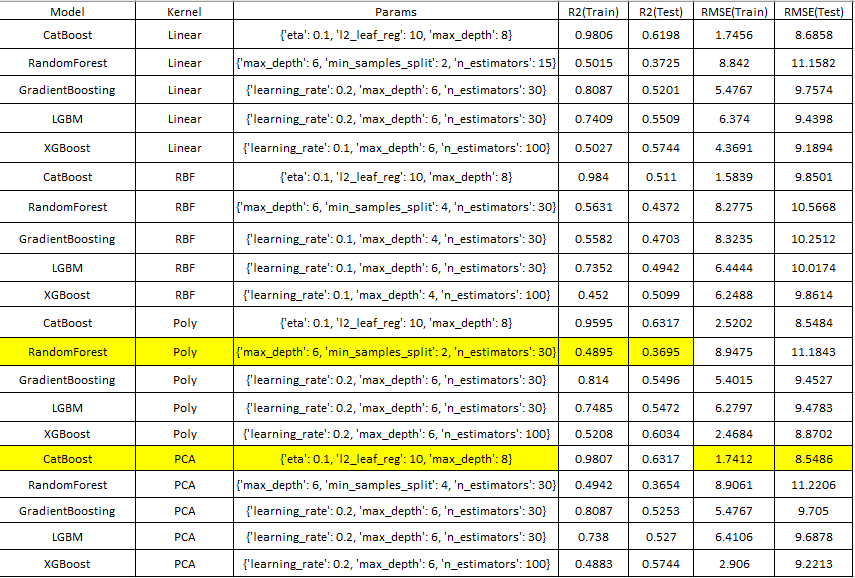

**Random Forest** with poly kernel and parameters {'max_depth'=6, 'min_samples_split'=2, 'n_estimators'=30} get the lowest error rate in R2 error.

**Categorical Boosting** with PCA and parameters {'eta'=0.1, 'l2_leaf_reg'=10, 'max_depth'=8} get the lowest error rate in RMSE score.

**I chose Random Forest** with above parameters because this is the evaluation metric that submitted in this competition with **0.3695 R2 error score.**